### Dataset

https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

- **Row ID**: Unique ID for each row.
- **Order ID**: Unique Order ID for each Customer.
- **Order Date**: Order Date of the product.
- **Ship Date**: Shipping Date of the Product.
- **Ship Mode**: Shipping Mode specified by the Customer.
- **Customer ID**: Unique ID to identify each Customer.
- **Customer Name**: Name of the Customer.
- **Segment**: The segment where the Customer belongs.
- **Country**: Country of residence of the Customer.
- **City**: City of residence of of the Customer.
- **State**: State of residence of the Customer.
- **Postal Code**: Postal Code of every Customer.
- **Region**: Region where the Customer belong.
- **Product ID**: Unique ID of the Product.
- **Category**: Category of the product ordered.
- **Sub-Category**: Sub-Category of the product ordered.
- **Product Name**: Name of the Product
- **Sales**: Sales of the Product.
- **Quantity**: Quantity of the Product.
- **Discount**: Discount provided.
- **Profit**: Profit/Loss incurred.

### Mendefinisikan Pertanyaan

1) **Target Analisis:**
> Menganalisis performa penjualan dan profit untuk mengidentifikasi faktor utama yang memengaruhi profitabilitas, menemukan area bisnis yang merugi, serta memberikan insight strategis berbasis data.

2) **Pertanyaan:**
> - Faktor apa yang paling berpengaruh terhadap Profit: Sales, Quantity, atau Discount?
> - Apakah diskon benar-benar meningkatkan profit, atau justru menyebabkan kerugian?
> - Produk atau Sub-Category apa yang memiliki Sales tinggi tetapi Profit rendah/negatif?
> - Kategori dan Sub-Category mana yang paling menguntungkan dan paling merugikan?
> - Segmen pelanggan mana yang memberikan kontribusi profit terbesar?
> - Region atau wilayah mana yang memiliki kinerja profit terbaik dan terburuk?
> - Bagaimana tren Sales dan Profit dari waktu ke waktu?
> - Apakah terdapat pola musiman dalam penjualan dan profit?
> - Ship Mode mana yang paling sering digunakan dan bagaimana pengaruhnya terhadap profit?

### Data Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import chardet
import warnings
warnings.filterwarnings('ignore')

import os
for dirname, _, filenames in os.walk('./dataset'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./dataset\Sample - Superstore.csv


In [2]:
with open('./dataset/Sample - Superstore.csv', 'rb') as f:
    print(chardet.detect(f.read()))

{'encoding': 'Windows-1252', 'confidence': 0.73, 'language': ''}


In [3]:
df = pd.read_csv('./dataset/Sample - Superstore.csv', encoding='Windows-1252')

In [4]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


### Preprocessing

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,9994.0,4997.500000,2885.163629,1.000,2499.25000,4997.5000,7495.750,9994.000
Postal Code,9994.0,55190.379428,32063.693350,1040.000,23223.00000,56430.5000,90008.000,99301.000
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976


In [9]:
df.describe(include='object').T

,count,unique,top,freq
Order ID,9994,5009,CA-2017-100111,14
Order Date,9994,1237,9/5/2016,38
Ship Date,9994,1334,12/16/2015,35
Ship Mode,9994,4,Standard Class,5968
Customer ID,9994,793,WB-21850,37
Customer Name,9994,793,William Brown,37
Segment,9994,3,Consumer,5191
Country,9994,1,United States,9994
City,9994,531,New York City,915
State,9994,49,California,2001


In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

### EDA

#### Faktor apa yang paling berpengaruh terhadap Profit: Sales, Quantity, atau Discount?

In [11]:
df[['Profit', 'Sales', 'Quantity', 'Discount']].describe()

,Profit,Sales,Quantity,Discount
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,28.656896,229.858001,3.789574,0.156203
std,234.260108,623.245101,2.225110,0.206452
min,-6599.978000,0.444000,1.000000,0.000000
25%,1.728750,17.280000,2.000000,0.000000
50%,8.666500,54.490000,3.000000,0.200000
75%,29.364000,209.940000,5.000000,0.200000
max,8399.976000,22638.480000,14.000000,0.800000


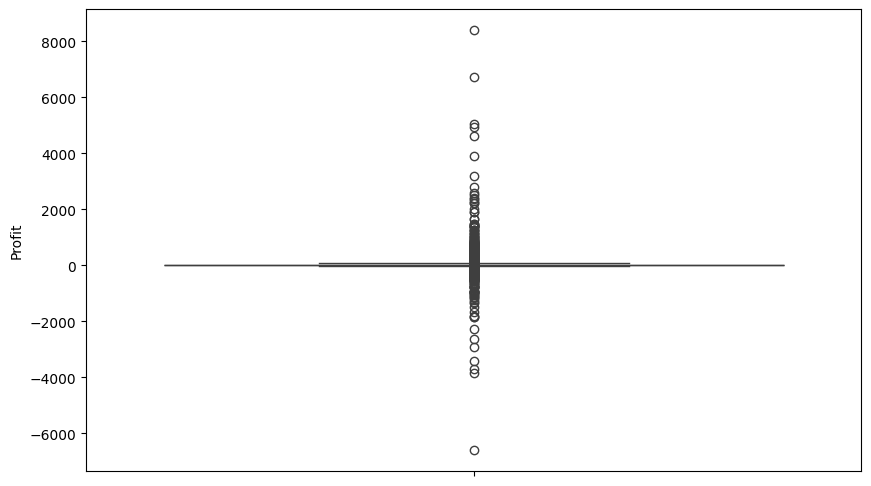

In [12]:
plt.figure(figsize=(10,6))
sns.boxplot(df['Profit'])
plt.show()

In [13]:
df[['Profit', 'Sales', 'Quantity', 'Discount']].corr()

,Profit,Sales,Quantity,Discount
Profit,1.000000,0.479064,0.066253,-0.219487
Sales,0.479064,1.000000,0.200795,-0.028190
Quantity,0.066253,0.200795,1.000000,0.008623
Discount,-0.219487,-0.028190,0.008623,1.000000


Sales

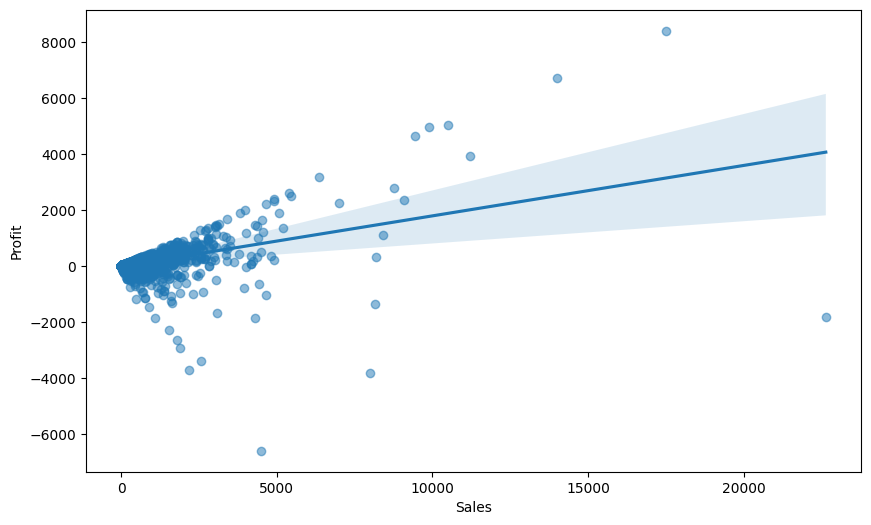

In [14]:
plt.figure(figsize=(10,6))
sns.regplot(
    data=df,
    x='Sales',
    y='Profit',
    scatter_kws={'alpha':0.5}
)
plt.show()

Quantity

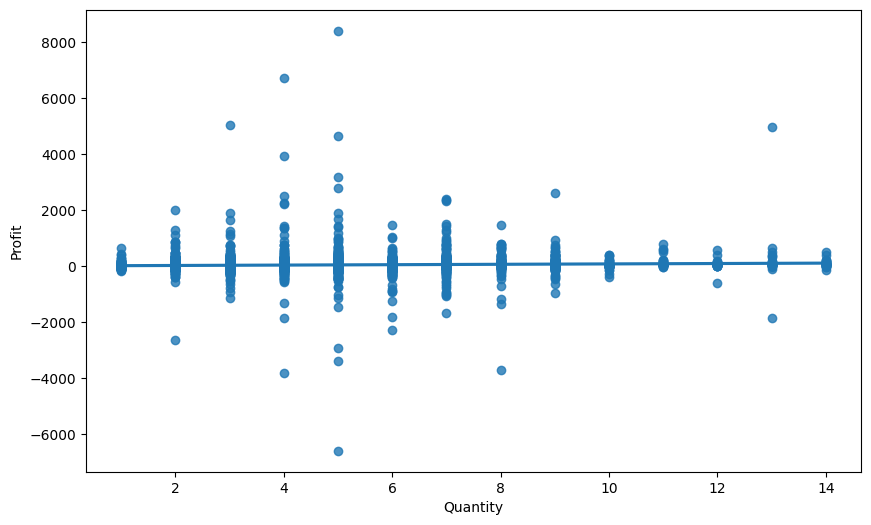

In [15]:
plt.figure(figsize=(10,6))
sns.regplot(data=df, x='Quantity', y='Profit')
plt.show()

Discount

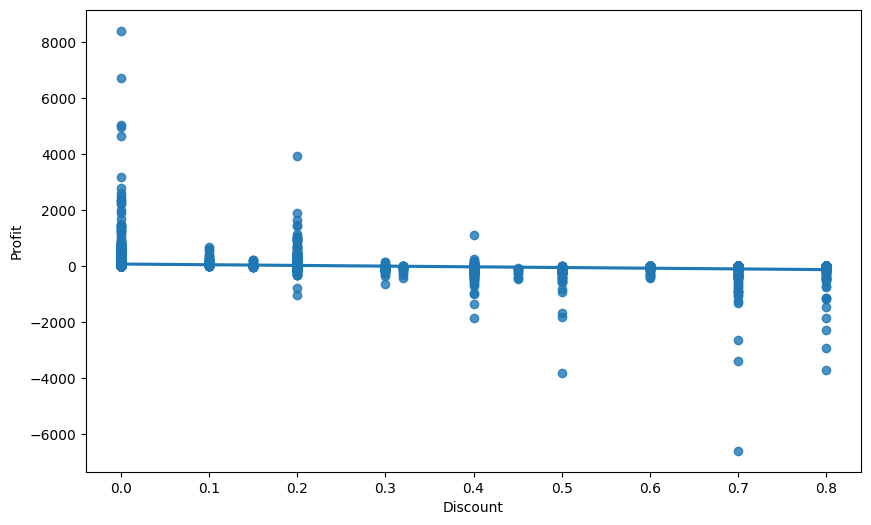

In [16]:
plt.figure(figsize=(10,6))
sns.regplot(data=df, x='Discount', y='Profit')
plt.show()

#### Apakah diskon benar-benar meningkatkan profit, atau justru menyebabkan kerugian?

Berdasarkan grafik dan analisis korelasi, diskon menunjukkan hubungan negatif terhadap profit. Semakin besar diskon yang diberikan, profit cenderung menurun dan pada banyak kasus menghasilkan nilai profit negatif. Hal ini mengindikasikan bahwa diskon tidak selalu meningkatkan profit dan justru berpotensi menyebabkan kerugian.

#### Produk atau Sub-Category apa yang memiliki Sales tinggi tetapi Profit rendah/negatif?

In [17]:
df[['Sub-Category', 'Product Name']].describe()

,Sub-Category,Product Name
count,9994,9994
unique,17,1850
top,Binders,Staple envelope
freq,1523,48


In [18]:
df[['Sales', 'Profit']].describe()

,Sales,Profit
count,9994.000000,9994.000000
mean,229.858001,28.656896
std,623.245101,234.260108
min,0.444000,-6599.978000
25%,17.280000,1.728750
50%,54.490000,8.666500
75%,209.940000,29.364000
max,22638.480000,8399.976000


Product Name

In [19]:
product_stats = (
    df.groupby('Product Name')
    .agg({'Sales': 'sum', 'Profit': 'sum'})
    .reset_index()
)
top_sales = product_stats.nlargest(25, 'Sales')
high_sales_low_profit = top_sales[top_sales['Profit'] <= 0]

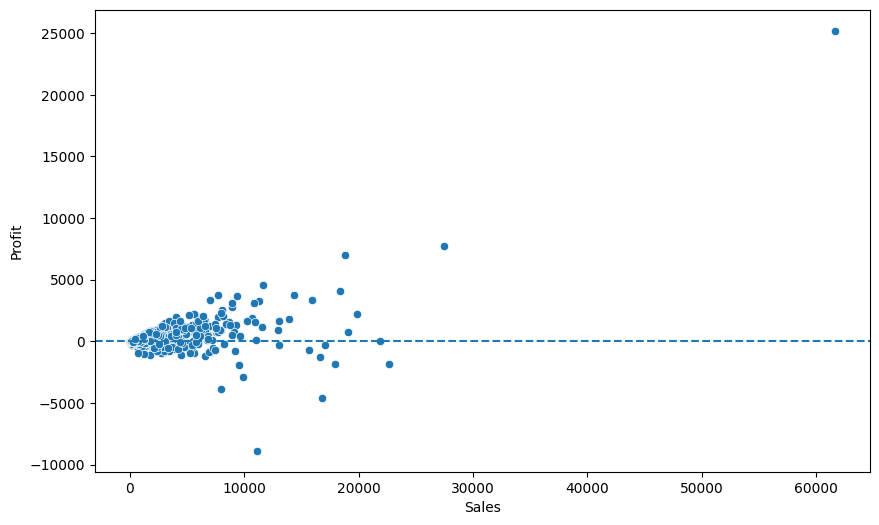

In [20]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=product_stats, 
    x='Sales', 
    y='Profit'
)
plt.axhline(0, linestyle='--')
plt.show()

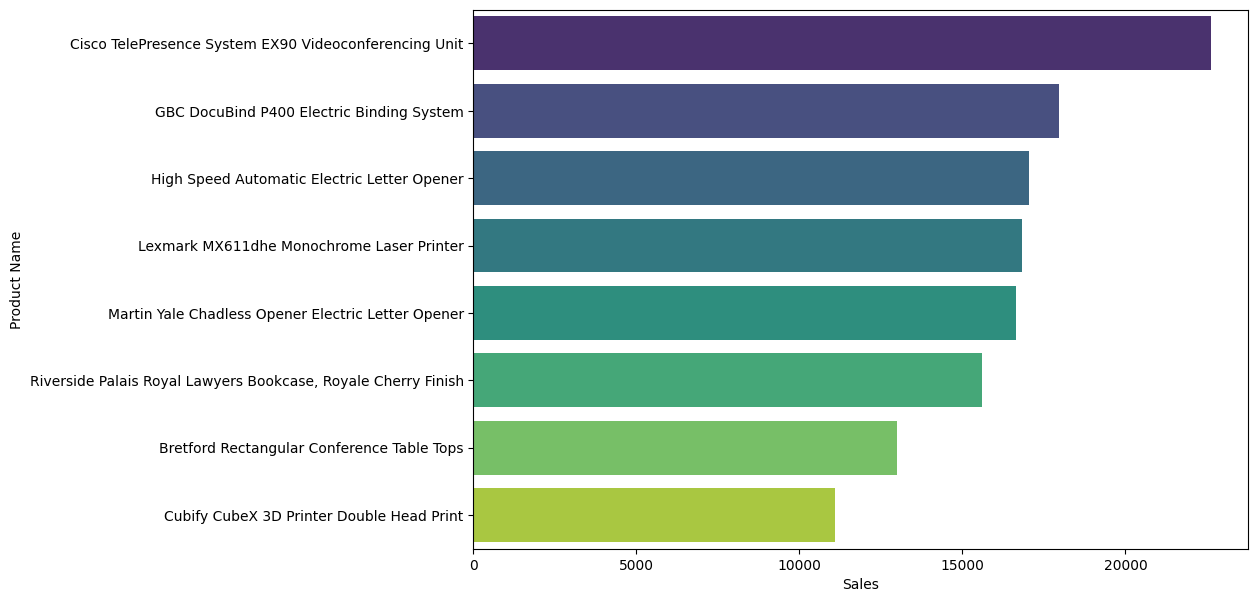

In [21]:
problem_products = high_sales_low_profit.sort_values('Sales', ascending=False)

plt.figure(figsize=(10,7))
sns.barplot(
    data=problem_products,
    x='Sales',
    y='Product Name',
    palette='viridis'
)
plt.show()

In [22]:
problem_products

,Product Name,Sales,Profit
444,Cisco TelePresence System EX90 Videoconferenci...,22638.4800,-1811.0784
683,GBC DocuBind P400 Electric Binding System,17965.0680,-1878.1662
813,High Speed Automatic Electric Letter Opener,17030.3120,-262.0048
985,Lexmark MX611dhe Monochrome Laser Printer,16829.9010,-4589.9730
1043,Martin Yale Chadless Opener Electric Letter Op...,16656.2000,-1299.1836
1351,"Riverside Palais Royal Lawyers Bookcase, Royal...",15610.9656,-669.5448
368,Bretford Rectangular Conference Table Tops,12995.2915,-327.2331
475,Cubify CubeX 3D Printer Double Head Print,11099.9630,-8879.9704


Sub-Category

In [23]:
sub_ctg_stats = (
    df.groupby('Sub-Category')
    .agg({
        'Sales': 'sum',
        'Profit': 'sum'
    })
    .reset_index()
)
sub_ctg_hsales_lprofit = sub_ctg_stats[sub_ctg_stats['Profit'] <= 0]

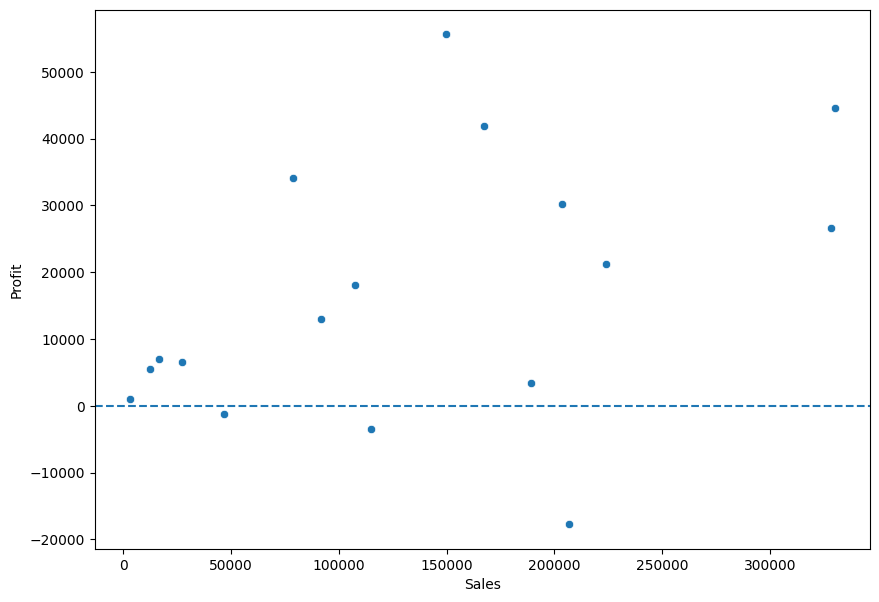

In [24]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=sub_ctg_stats,
    x='Sales',
    y='Profit'
)
plt.axhline(0, linestyle='--')
plt.show()

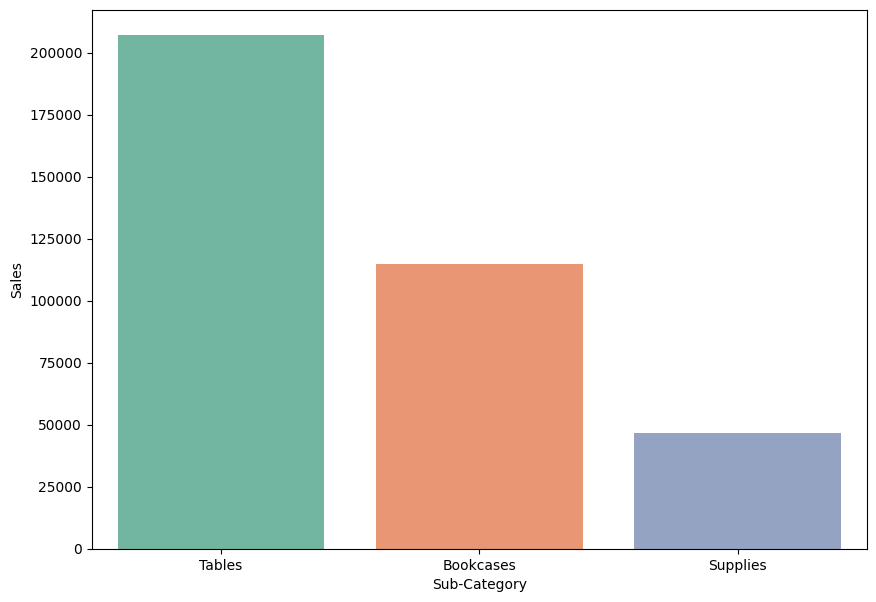

In [25]:
problem_sub_ctg = sub_ctg_hsales_lprofit.sort_values('Sales', ascending=False)

plt.figure(figsize=(10,7))
sns.barplot(
    data=problem_sub_ctg,
    x='Sub-Category',
    y='Sales',
    palette='Set2'
)
plt.show()

In [26]:
problem_sub_ctg

,Sub-Category,Sales,Profit
16,Tables,206965.5320,-17725.4811
4,Bookcases,114879.9963,-3472.5560
15,Supplies,46673.5380,-1189.0995


**Insight:**
> Berdasarkan hasil analisis, terdapat beberapa produk dan sub-category yang mencatat nilai sales tinggi namun menghasilkan profit rendah hingga negatif. Temuan ini menunjukkan bahwa tingginya penjualan tidak selalu berbanding lurus dengan keuntungan yang diperoleh perusahaan. Secara keseluruhan, hasil ini menegaskan bahwa strategi peningkatan sales perlu diimbangi dengan pengelolaan margin dan diskon yang tepat agar tidak berdampak negatif terhadap profitabilitas.

#### Kategori dan Sub-Category mana yang paling menguntungkan dan paling merugikan?

In [27]:
df[['Category', 'Sub-Category']].describe()

,Category,Sub-Category
count,9994,9994
unique,3,17
top,Office Supplies,Binders
freq,6026,1523


In [28]:
df['Profit'].describe()

count    9994.000000
mean       28.656896
std       234.260108
min     -6599.978000
25%         1.728750
50%         8.666500
75%        29.364000
max      8399.976000
Name: Profit, dtype: float64

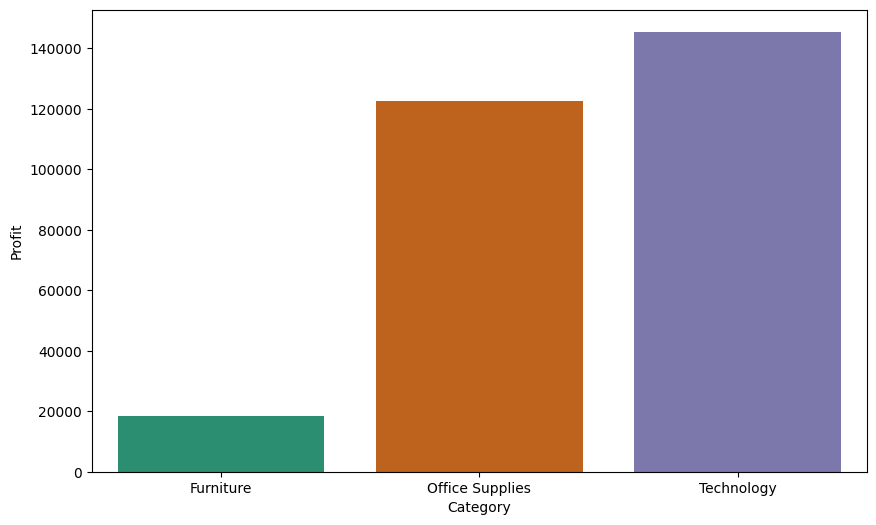

In [29]:
plt.figure(figsize=(10,6))
profit_ctg = df.groupby('Category')['Profit'].sum().reset_index()
sns.barplot(
    data=profit_ctg,
    x='Category',
    y='Profit',
    palette='Dark2'
)

plt.show()

In [30]:
profit_ctg

,Category,Profit
0,Furniture,18451.2728
1,Office Supplies,122490.8008
2,Technology,145454.9481


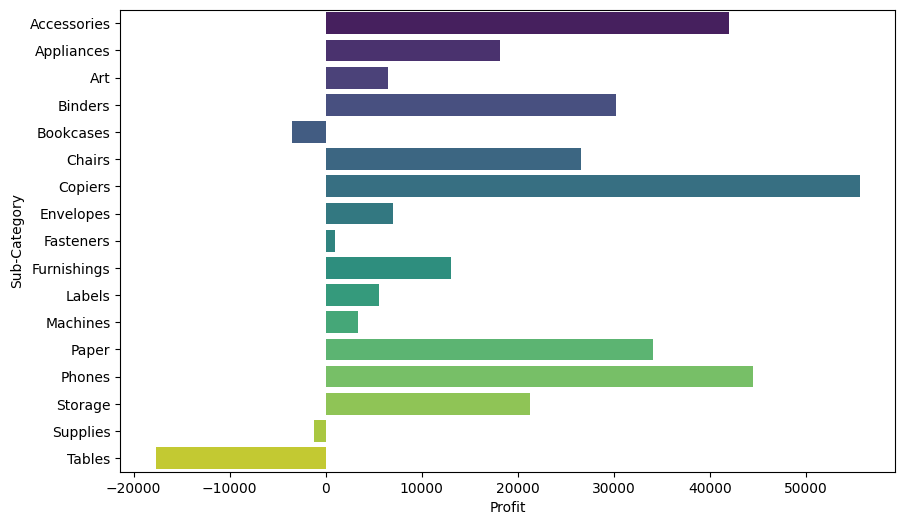

In [31]:
plt.figure(figsize=(10,6))
profit_sub_ctg = df.groupby('Sub-Category')['Profit'].sum().reset_index()
sns.barplot(
    data=profit_sub_ctg,
    x='Profit',
    y='Sub-Category',
    palette='viridis'
)

plt.show()

In [32]:
profit_sub_ctg

,Sub-Category,Profit
0,Accessories,41936.6357
1,Appliances,18138.0054
2,Art,6527.7870
3,Binders,30221.7633
4,Bookcases,-3472.5560
5,Chairs,26590.1663
6,Copiers,55617.8249
7,Envelopes,6964.1767
8,Fasteners,949.5182
9,Furnishings,13059.1436


**Insight:**
> Berdasarkan hasil analisis, Technology merupakan kategori yang paling menguntungkan dengan total profit tertinggi, sementara Furniture memiliki profit terendah dibandingkan kategori lainnya meskipun masih bernilai positif.
 
> Pada level sub-category, Copiers menjadi sub-category paling menguntungkan dengan kontribusi profit terbesar. Sebaliknya, Tables merupakan sub-category paling merugikan dengan nilai profit negatif yang signifikan, diikuti oleh Bookcases dan Supplies.

#### Segmen pelanggan mana yang memberikan kontribusi profit terbesar?

In [33]:
df['Segment'].describe()

count         9994
unique           3
top       Consumer
freq          5191
Name: Segment, dtype: object

In [34]:
df['Profit'].describe()

count    9994.000000
mean       28.656896
std       234.260108
min     -6599.978000
25%         1.728750
50%         8.666500
75%        29.364000
max      8399.976000
Name: Profit, dtype: float64

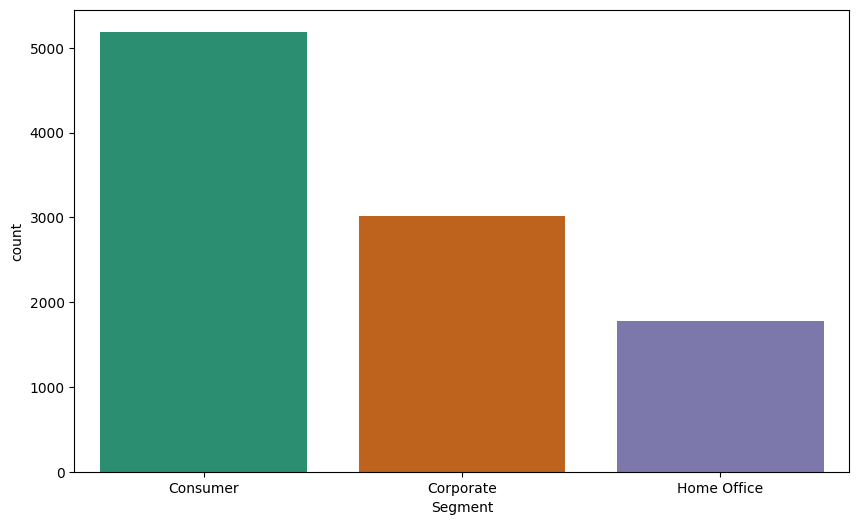

In [35]:
plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    x='Segment',
    palette='Dark2'
)

plt.show()

In [36]:
df['Segment'].value_counts()

Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

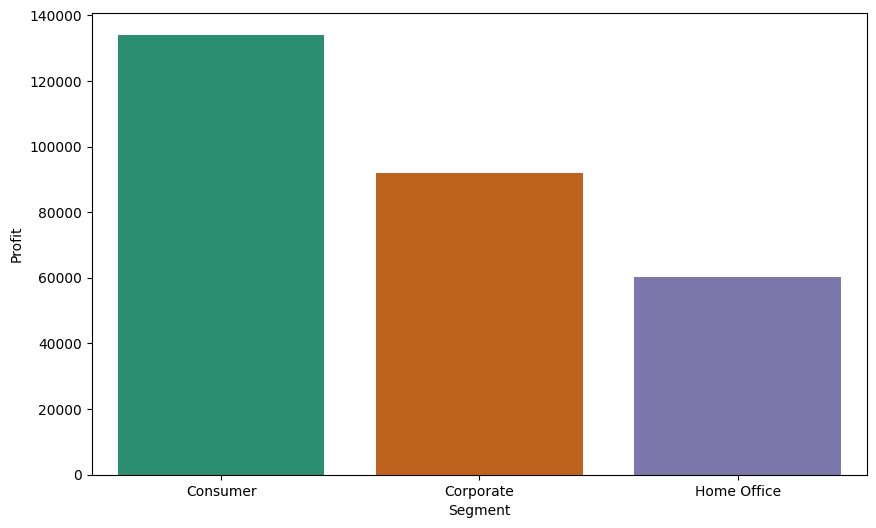

In [37]:
plt.figure(figsize=(10,6))
profit_segment = df.groupby('Segment')['Profit'].sum().reset_index()
sns.barplot(
    data=profit_segment,
    x='Segment',
    y='Profit',
    palette='Dark2'
)

plt.show()

In [38]:
df.groupby('Segment')['Profit'].sum().reset_index()

,Segment,Profit
0,Consumer,134119.2092
1,Corporate,91979.1340
2,Home Office,60298.6785


In [39]:
df.groupby('Segment')['Profit'].mean().reset_index()

,Segment,Profit
0,Consumer,25.836873
1,Corporate,30.456667
2,Home Office,33.818664


**Insight:**
> Segmen Consumer merupakan segmen pelanggan yang paling sering bertransaksi dan memberikan kontribusi profit terbesar secara total. Namun, jika dilihat dari sisi rata-rata profit per transaksi, segmen Consumer memiliki nilai yang lebih rendah dibandingkan Corporate dan Home Office. Hal ini menunjukkan bahwa tingginya kontribusi profit Consumer didorong oleh volume transaksi, bukan profit per transaksi yang tinggi.

#### Region atau wilayah mana yang memiliki kinerja profit terbaik dan terburuk?

In [40]:
df[['City', 'State', 'Region']].describe()

,City,State,Region
count,9994,9994,9994
unique,531,49,4
top,New York City,California,West
freq,915,2001,3203


In [41]:
df['City'].unique()

array(['Henderson', 'Los Angeles', 'Fort Lauderdale', 'Concord',
       'Seattle', 'Fort Worth', 'Madison', 'West Jordan', 'San Francisco',
       'Fremont', 'Philadelphia', 'Orem', 'Houston', 'Richardson',
       'Naperville', 'Melbourne', 'Eagan', 'Westland', 'Dover',
       'New Albany', 'New York City', 'Troy', 'Chicago', 'Gilbert',
       'Springfield', 'Jackson', 'Memphis', 'Decatur', 'Durham',
       'Columbia', 'Rochester', 'Minneapolis', 'Portland', 'Saint Paul',
       'Aurora', 'Charlotte', 'Orland Park', 'Urbandale', 'Columbus',
       'Bristol', 'Wilmington', 'Bloomington', 'Phoenix', 'Roseville',
       'Independence', 'Pasadena', 'Newark', 'Franklin', 'Scottsdale',
       'San Jose', 'Edmond', 'Carlsbad', 'San Antonio', 'Monroe',
       'Fairfield', 'Grand Prairie', 'Redlands', 'Hamilton', 'Westfield',
       'Akron', 'Denver', 'Dallas', 'Whittier', 'Saginaw', 'Medina',
       'Dublin', 'Detroit', 'Tampa', 'Santa Clara', 'Lakeville',
       'San Diego', 'Brentwood', 'Cha

In [42]:
df['State'].unique()

array(['Kentucky', 'California', 'Florida', 'North Carolina',
       'Washington', 'Texas', 'Wisconsin', 'Utah', 'Nebraska',
       'Pennsylvania', 'Illinois', 'Minnesota', 'Michigan', 'Delaware',
       'Indiana', 'New York', 'Arizona', 'Virginia', 'Tennessee',
       'Alabama', 'South Carolina', 'Oregon', 'Colorado', 'Iowa', 'Ohio',
       'Missouri', 'Oklahoma', 'New Mexico', 'Louisiana', 'Connecticut',
       'New Jersey', 'Massachusetts', 'Georgia', 'Nevada', 'Rhode Island',
       'Mississippi', 'Arkansas', 'Montana', 'New Hampshire', 'Maryland',
       'District of Columbia', 'Kansas', 'Vermont', 'Maine',
       'South Dakota', 'Idaho', 'North Dakota', 'Wyoming',
       'West Virginia'], dtype=object)

In [43]:
df['Region'].unique()

array(['South', 'West', 'Central', 'East'], dtype=object)

City

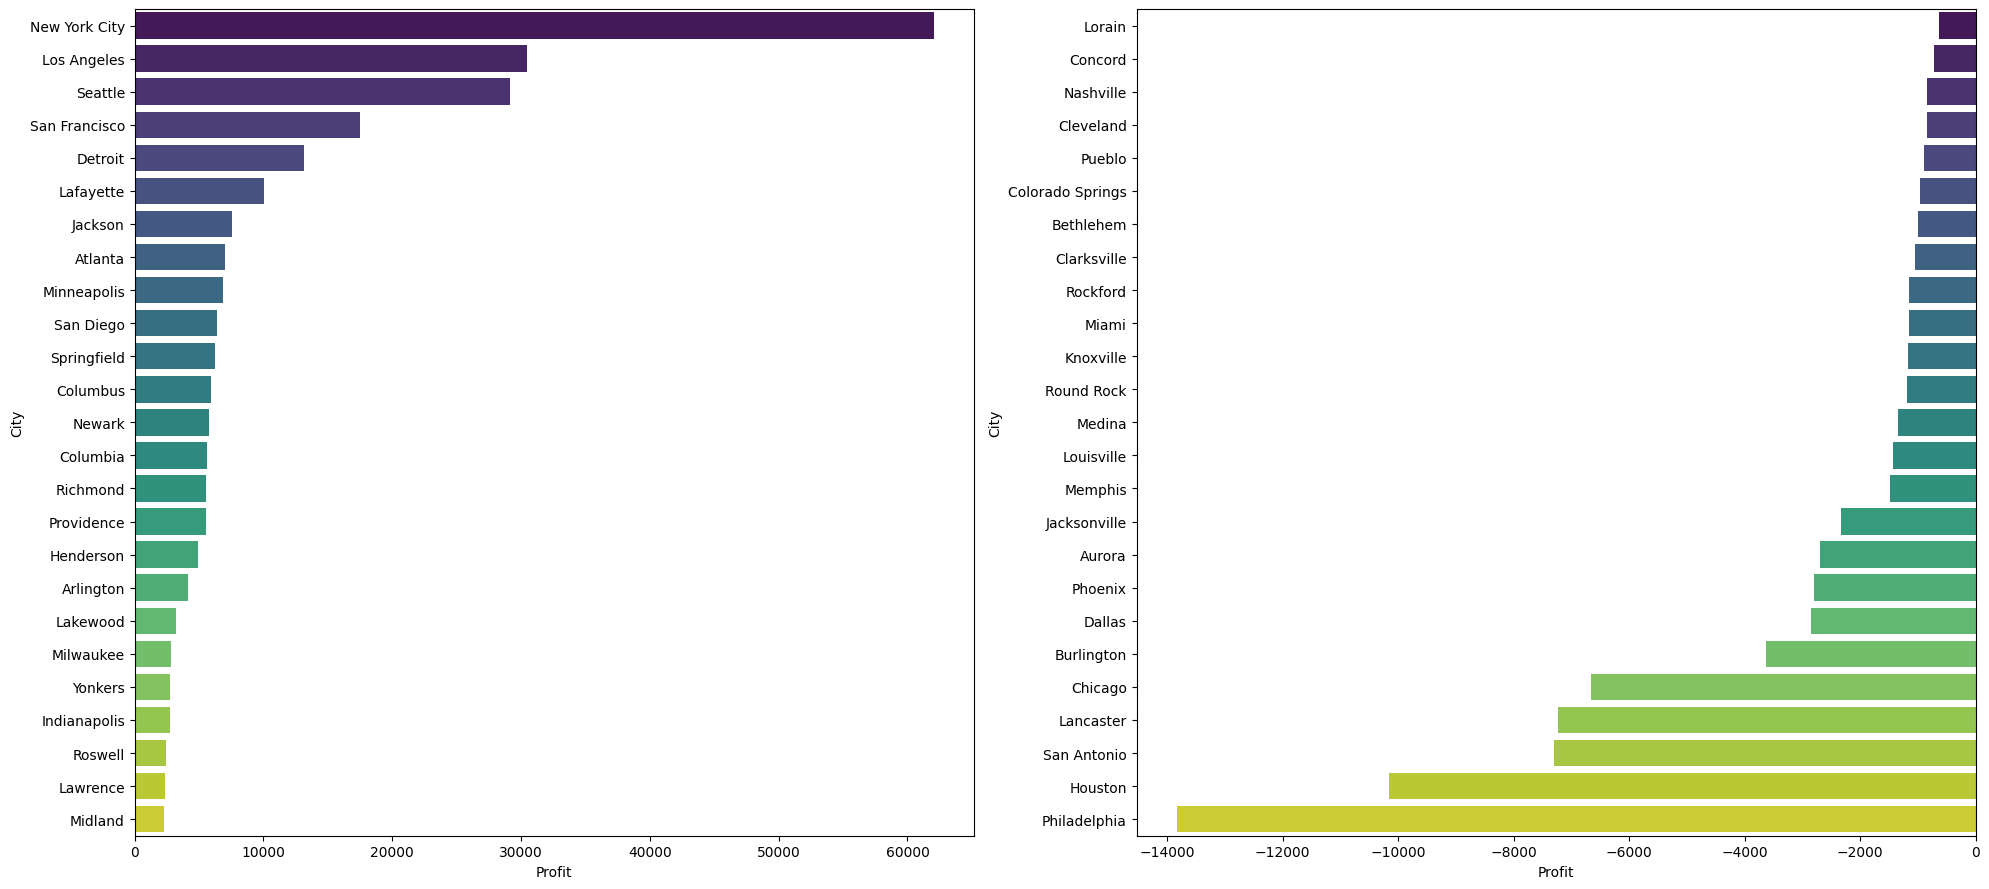

In [44]:
plt.figure(figsize=(20,9))

plt.subplot(1, 2, 1)
profit_city_largest = df.groupby('City')['Profit'].sum().nlargest(25).reset_index()
sns.barplot(
    data=profit_city_largest,
    x='Profit',
    y='City',
    palette='viridis'
)

plt.subplot(1, 2, 2)
profit_city_smallest = df.groupby('City')['Profit'].sum().nsmallest(25).reset_index().sort_values(by='Profit', ascending=False)
sns.barplot(
    data=profit_city_smallest,
    x='Profit',
    y='City',
    palette='viridis'
)

plt.tight_layout()
plt.show()

In [45]:
df.groupby('City')['Profit'].sum().reset_index()

,City,Profit
0,Aberdeen,6.6300
1,Abilene,-3.7584
2,Akron,-186.6356
3,Albuquerque,634.0881
4,Alexandria,318.6183
...,...,...
526,Woonsocket,78.6791
527,Yonkers,2767.7557
528,York,-102.1692
529,Yucaipa,13.2080


In [46]:
profit_city_largest.loc[profit_city_largest['Profit'].idxmax()]

City      New York City
Profit       62036.9837
Name: 0, dtype: object

In [47]:
profit_city_smallest.loc[profit_city_smallest['Profit'].idxmin()]

City      Philadelphia
Profit     -13837.7674
Name: 0, dtype: object

State

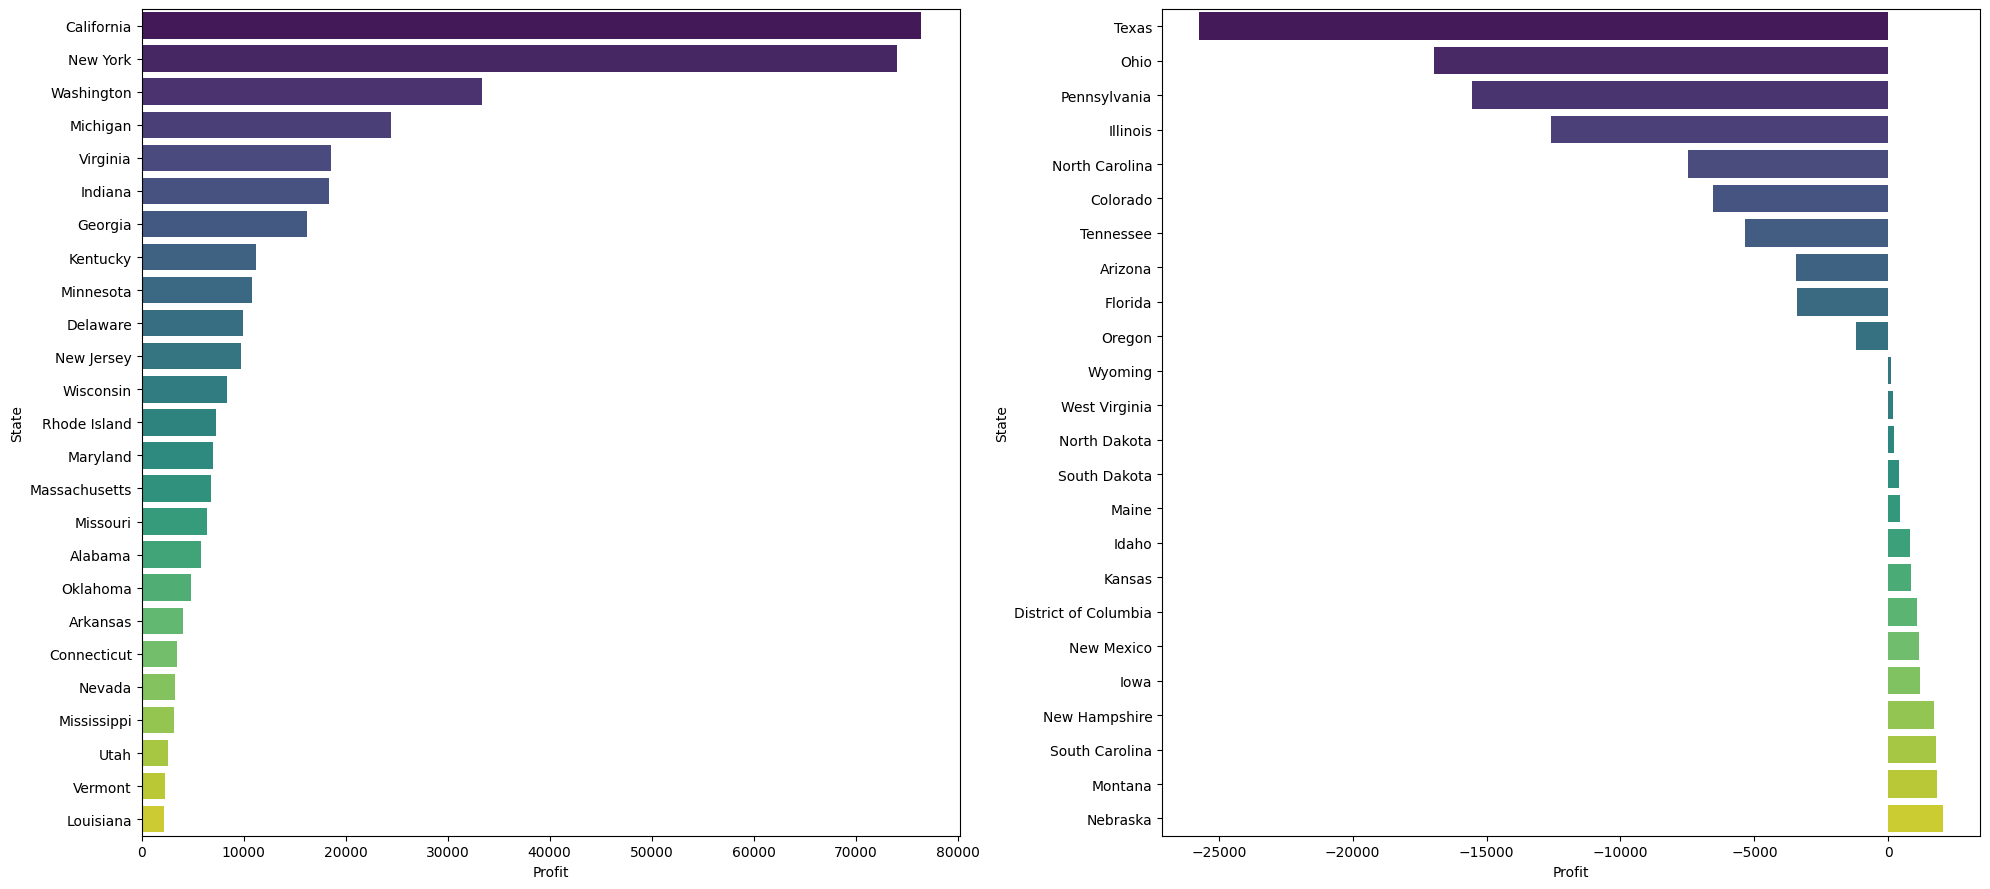

In [48]:
plt.figure(figsize=(20,9))

plt.subplot(1, 2, 1)
profit_state_largest = df.groupby('State')['Profit'].sum().nlargest(25).reset_index()
sns.barplot(
    data=profit_state_largest,
    x='Profit',
    y='State',
    palette='viridis'
)

plt.subplot(1, 2, 2)
profit_state_smallest = df.groupby('State')['Profit'].sum().nsmallest(24).reset_index()
sns.barplot(
    data=profit_state_smallest,
    x='Profit',
    y='State',
    palette='viridis'
)

plt.tight_layout()
plt.show()

In [49]:
df.groupby('State')['Profit'].sum().reset_index()

,State,Profit
0,Alabama,5786.8253
1,Arizona,-3427.9246
2,Arkansas,4008.6871
3,California,76381.3871
4,Colorado,-6527.8579
5,Connecticut,3511.4918
6,Delaware,9977.3748
7,District of Columbia,1059.5893
8,Florida,-3399.3017
9,Georgia,16250.0433


In [50]:
profit_state_largest.loc[profit_state_largest['Profit'].idxmax()]

State     California
Profit    76381.3871
Name: 0, dtype: object

In [51]:
profit_state_smallest.loc[profit_state_smallest['Profit'].idxmin()]

State          Texas
Profit   -25729.3563
Name: 0, dtype: object

Region

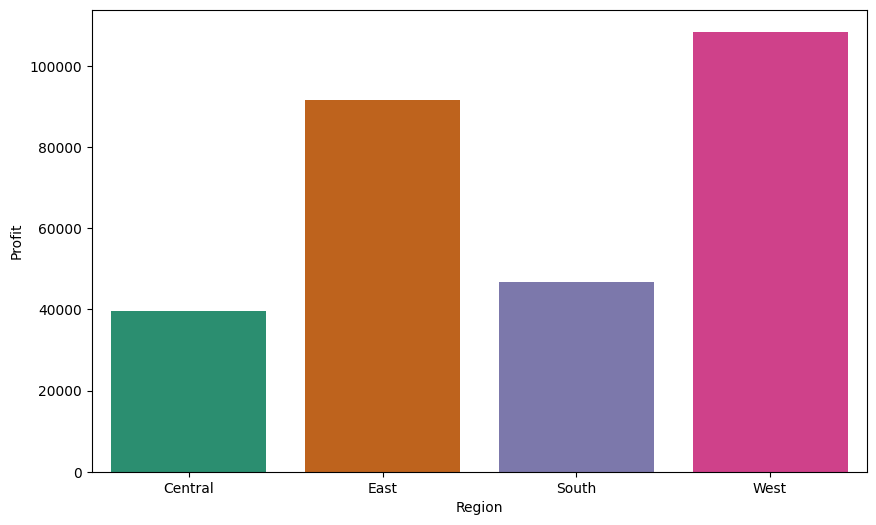

In [52]:
plt.figure(figsize=(10,6))
profit_region = df.groupby('Region')['Profit'].sum().reset_index()
sns.barplot(
    data=profit_region,
    x='Region',
    y='Profit',
    palette='Dark2'
)

plt.show()

In [53]:
profit_region

,Region,Profit
0,Central,39706.3625
1,East,91522.7800
2,South,46749.4303
3,West,108418.4489


**Insight:**
> Berdasarkan hasil analisis profit secara geografis, wilayah West merupakan region dengan kinerja profit terbaik, mencatat total profit tertinggi dibandingkan region lainnya. Sebaliknya, Central menjadi region dengan profit terendah meskipun masih bernilai positif.

> Pada tingkat negara bagian (state), California mencatat profit tertinggi, sementara Texas mengalami kerugian terbesar dengan nilai profit negatif.

> Pada tingkat kota (city), New York City menjadi kota dengan kontribusi profit terbesar, sedangkan Philadelphia merupakan kota dengan performa terburuk karena menghasilkan profit negatif.

#### Bagaimana tren Sales dan Profit dari waktu ke waktu?

In [54]:
df['Order Date'].describe()

count                             9994
mean     2016-04-30 00:07:12.259355648
min                2014-01-03 00:00:00
25%                2015-05-23 00:00:00
50%                2016-06-26 00:00:00
75%                2017-05-14 00:00:00
max                2017-12-30 00:00:00
Name: Order Date, dtype: object

In [55]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_name'] = df['Order Date'].dt.month_name()

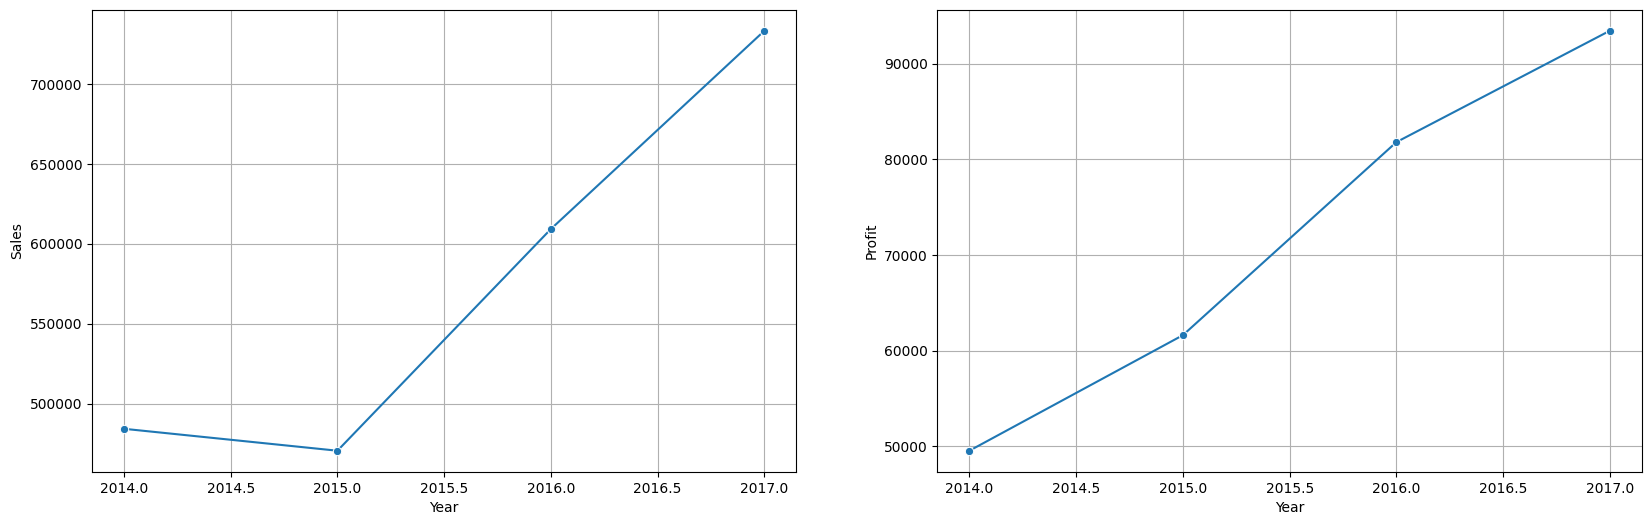

,Year,Sales,Profit
0,2014,484247.4981,49543.9741
1,2015,470532.5090,61618.6037
2,2016,609205.5980,81795.1743
3,2017,733215.2552,93439.2696


In [56]:
plt.figure(figsize=(20,6))

year_trend = (
    df.groupby('Year')
    .agg({
        'Sales': 'sum',
        'Profit': 'sum'
    })
    .reset_index()
)

plt.subplot(1, 2, 1)
sns.lineplot(
    data=year_trend,
    x='Year',
    y='Sales',
    marker='o'
)
plt.grid()

plt.subplot(1, 2, 2)
sns.lineplot(
    data=year_trend,
    x='Year',
    y='Profit',
    marker='o'
)
plt.grid()


plt.show()

year_trend

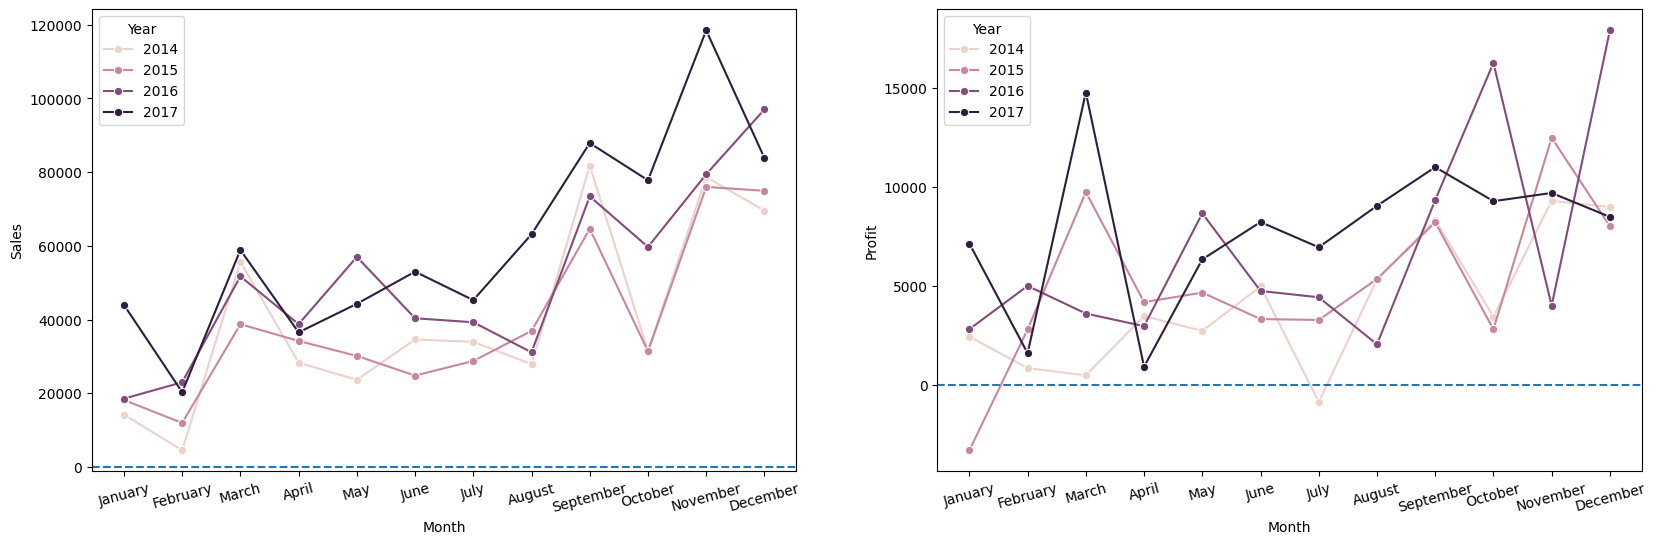

,Year,Month,Month_name,Sales,Profit
0,2014,1,January,14236.8950,2450.1907
1,2014,2,February,4519.8920,862.3084
2,2014,3,March,55691.0090,498.7299
3,2014,4,April,28295.3450,3488.8352
4,2014,5,May,23648.2870,2738.7096
5,2014,6,June,34595.1276,4976.5244
6,2014,7,July,33946.3930,-841.4826
7,2014,8,August,27909.4685,5318.1050
8,2014,9,September,81777.3508,8328.0994
9,2014,10,October,31453.3930,3448.2573


In [57]:
monthly_perf = (
    df.groupby(['Year', 'Month', 'Month_name'])
    .agg({
        'Sales': 'sum',
        'Profit': 'sum'
    })
    .reset_index()
    .sort_values(['Year', 'Month'])
)

plt.figure(figsize=(20,6))

plt.subplot(1, 2, 1)
sns.lineplot(
    data=monthly_perf,
    x='Month',
    y='Sales',
    hue='Year',
    marker='o'
)
plt.xticks(range(1, 13), monthly_perf['Month_name'].unique(), rotation=15)
plt.axhline(0, linestyle='--')

plt.subplot(1, 2, 2)
sns.lineplot(
    data=monthly_perf,
    x='Month',
    y='Profit',
    hue='Year',
    marker='o'
)
plt.xticks(range(1, 13), monthly_perf['Month_name'].unique(), rotation=15)
plt.axhline(0, linestyle='--')

plt.show()

monthly_perf

**Insight:**
> Berdasarkan analisis tren waktu, sales dan profit menunjukkan kecenderungan meningkat dari tahun 2014 hingga 2017, dengan performa terbaik terjadi pada tahun 2017. Meskipun sales sempat mengalami penurunan pada 2015 dibandingkan tahun sebelumnya, profit justru meningkat, yang mengindikasikan adanya perbaikan efisiensi atau margin. Pada tingkat bulanan, terlihat pola musiman yang konsisten, di mana sales dan profit cenderung lebih tinggi pada paruh kedua tahun, khususnya pada periode September hingga November, sementara awal tahun seperti Januari dan Februari menunjukkan performa yang relatif lebih rendah dan pada beberapa kasus menghasilkan profit negatif.

#### Apakah terdapat pola musiman dalam penjualan dan profit?

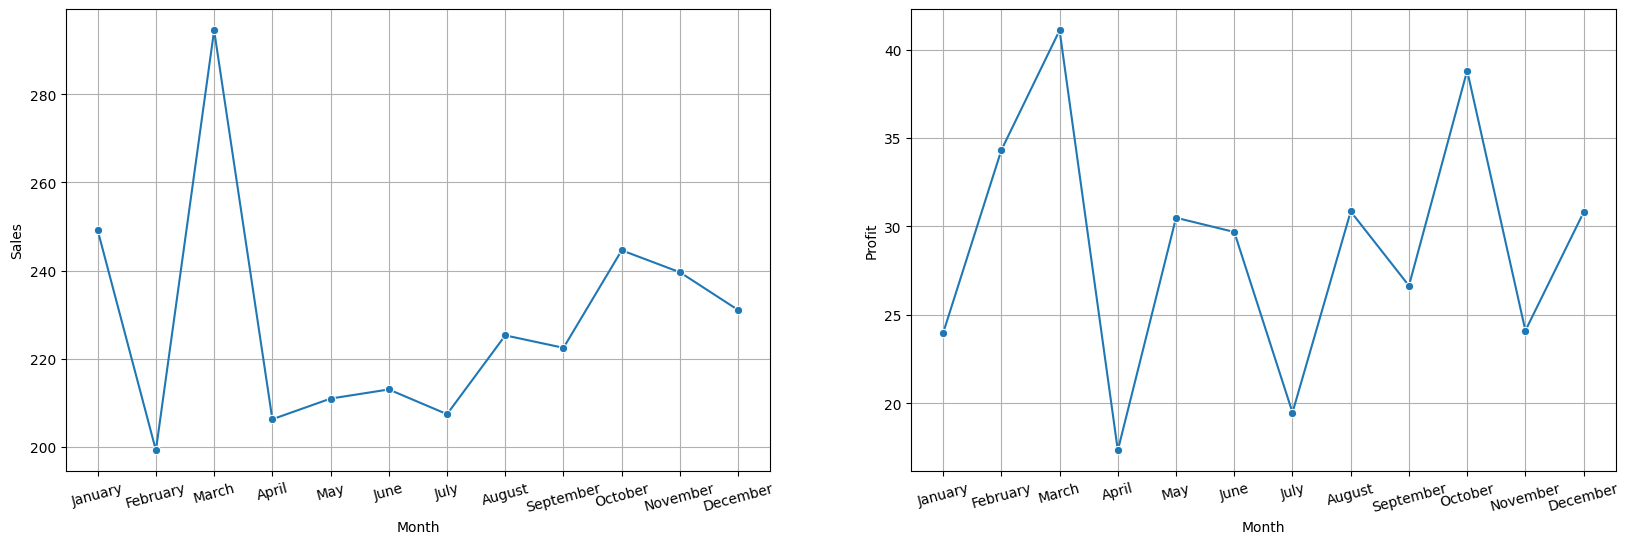

In [58]:
seasons = (
    df.groupby(['Month', 'Month_name'])
    .agg({
        'Sales': 'mean',
        'Profit': 'mean'
    })
    .reset_index()
    .sort_values('Month')
)

plt.figure(figsize=(20,6))

plt.subplot(1, 2, 1)
sns.lineplot(
    data=seasons,
    x='Month',
    y='Sales',
    marker='o'
)
plt.xticks(range(1, 13), seasons['Month_name'].unique(), rotation=15)
plt.grid()

plt.subplot(1, 2, 2)
sns.lineplot(
    data=seasons,
    x='Month',
    y='Profit',
    marker='o'
)
plt.xticks(range(1, 13), seasons['Month_name'].unique(), rotation=15)
plt.grid()

plt.show()

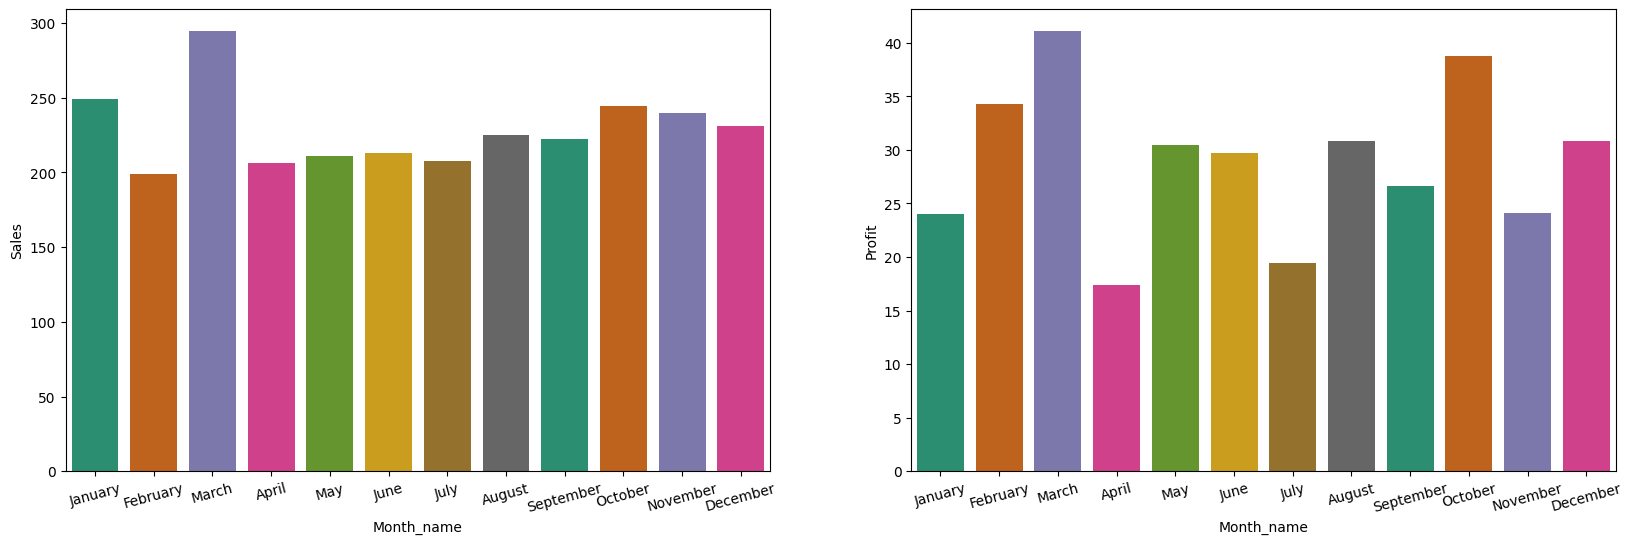

,Month,Month_name,Sales,Profit
0,1,January,249.146550,23.974924
1,2,February,199.170838,34.315369
2,3,March,294.548116,41.084321
3,4,April,206.230731,17.346462
4,5,May,210.923553,30.491575
5,6,June,212.996763,29.687302
6,7,July,207.377601,19.482626
7,8,August,225.274877,30.845522
8,9,September,222.451154,26.650380
9,10,October,244.594609,38.808353


In [59]:
plt.figure(figsize=(20,6))

plt.subplot(1, 2, 1)
sns.barplot(
    data=seasons,
    x='Month_name',
    y='Sales',
    palette='Dark2'
)
plt.xticks(rotation=15)

plt.subplot(1, 2, 2)
sns.barplot(
    data=seasons,
    x='Month_name',
    y='Profit',
    palette='Dark2'
)
plt.xticks(rotation=15)

plt.show()

seasons

In [60]:
best_month_profit = seasons.loc[seasons['Profit'].idxmax()]
best_month_profit

Month                  3
Month_name         March
Sales         294.548116
Profit         41.084321
Name: 2, dtype: object

In [61]:
worst_month = seasons.loc[seasons['Profit'].idxmin()]
worst_month

Month                  4
Month_name         April
Sales         206.230731
Profit         17.346462
Name: 3, dtype: object

**Insight:**
> Berdasarkan analisis rata-rata penjualan dan profit per bulan, terdapat pola musiman dalam kinerja bisnis. Penjualan dan profit cenderung lebih tinggi pada pertengahan hingga akhir tahun, khususnya pada bulan Maret, Oktober, dan November, yang menunjukkan periode dengan performa relatif lebih baik. Sebaliknya, bulan Januari, April, dan Juli menunjukkan nilai penjualan dan profit yang lebih rendah dibandingkan bulan lainnya. Pola ini mengindikasikan bahwa kinerja penjualan dan profit tidak merata sepanjang tahun dan dipengaruhi oleh faktor musiman.

#### Ship Mode mana yang paling sering digunakan dan bagaimana pengaruhnya terhadap profit?

In [62]:
df['Ship Mode'].describe()

count               9994
unique                 4
top       Standard Class
freq                5968
Name: Ship Mode, dtype: object

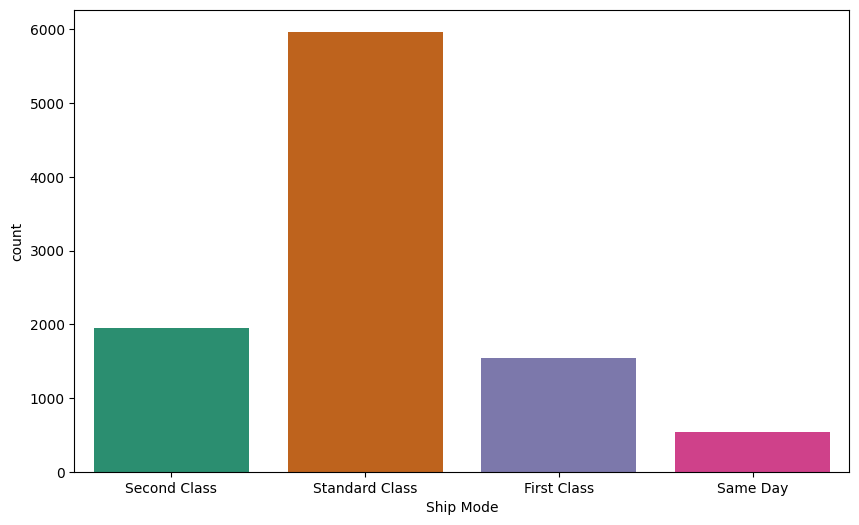

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

In [63]:
plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    x='Ship Mode',
    palette='Dark2'
)

plt.show()

df['Ship Mode'].value_counts()

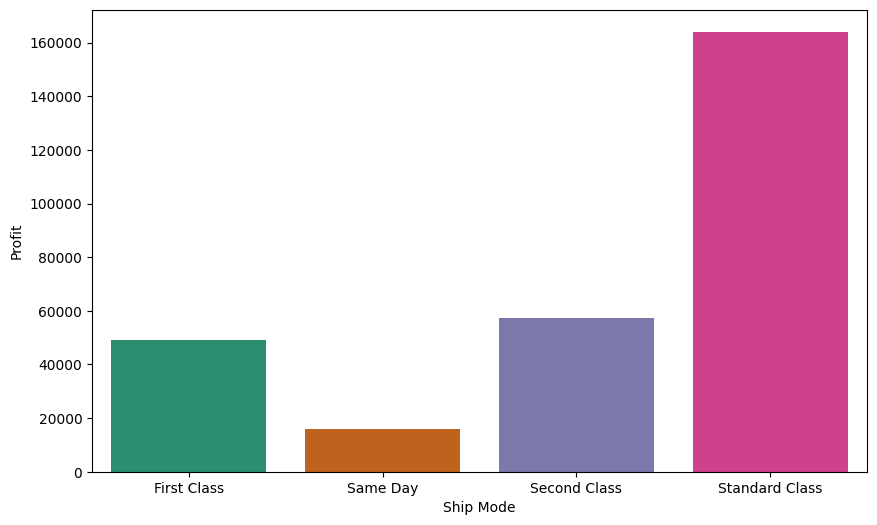

,Ship Mode,Profit
0,First Class,48969.8399
1,Same Day,15891.7589
2,Second Class,57446.6354
3,Standard Class,164088.7875


In [64]:
plt.figure(figsize=(10,6))
profit_ship = df.groupby('Ship Mode')['Profit'].sum().reset_index()
sns.barplot(
    data=profit_ship,
    x='Ship Mode',
    y='Profit',
    palette='Dark2'
)

plt.show()

profit_ship

**Insight:**
> Berdasarkan jumlah transaksi, Standard Class merupakan ship mode yang paling sering digunakan oleh pelanggan. Selain paling populer, Standard Class juga memberikan kontribusi profit terbesar dibandingkan ship mode lainnya. Meskipun Second Class dan First Class digunakan lebih jarang, keduanya tetap memberikan kontribusi profit yang cukup signifikan. Sementara itu, Same Day merupakan ship mode yang paling jarang digunakan dan menghasilkan profit paling rendah.

> Hasil ini menunjukkan bahwa ship mode yang paling sering digunakan juga cenderung memberikan kontribusi profit yang lebih besar, mengindikasikan bahwa Standard Class merupakan opsi pengiriman yang paling efisien dan menguntungkan bagi perusahaan.

### Forecasting

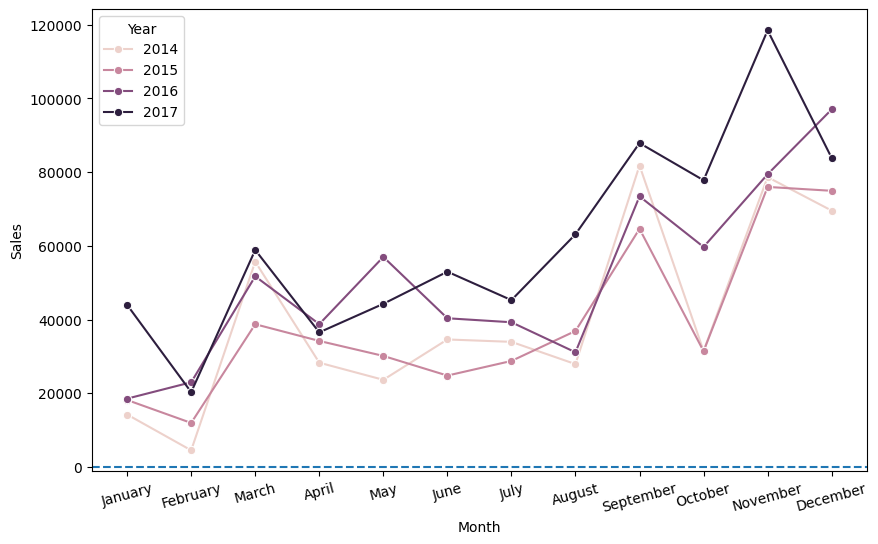

In [89]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=monthly_perf,
    x='Month',
    y='Sales',
    hue='Year',
    marker='o'
)
plt.xticks(range(1, 13), monthly_perf['Month_name'].unique(), rotation=15)
plt.axhline(0, linestyle='--')

plt.show()

> Pada dataset ini, berdasarkan EDA, dataset memiliki pola tren dan seasonality. Sehingga metode forecasting yang cocok adalah Holt-winters.

> Model perlu diuji coba kelayakan untuk melihat apakah metode ini baik untuk digunakan.

#### Uji Kelayakan Model

##### Step 1 - Tentukan Target

> Total Sales Per Bulan

##### Step 2 - Bentuk Time Series Bulanan

In [69]:
df['YearMonth'] = df['Order Date'].dt.to_period('M')
df['YearMonth']

0       2016-11
1       2016-11
2       2016-06
3       2015-10
4       2015-10
         ...   
9989    2014-01
9990    2017-02
9991    2017-02
9992    2017-02
9993    2017-05
Name: YearMonth, Length: 9994, dtype: period[M]

In [74]:
monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()

In [75]:
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].dt.to_timestamp()

In [76]:
monthly_sales = monthly_sales.set_index('YearMonth')

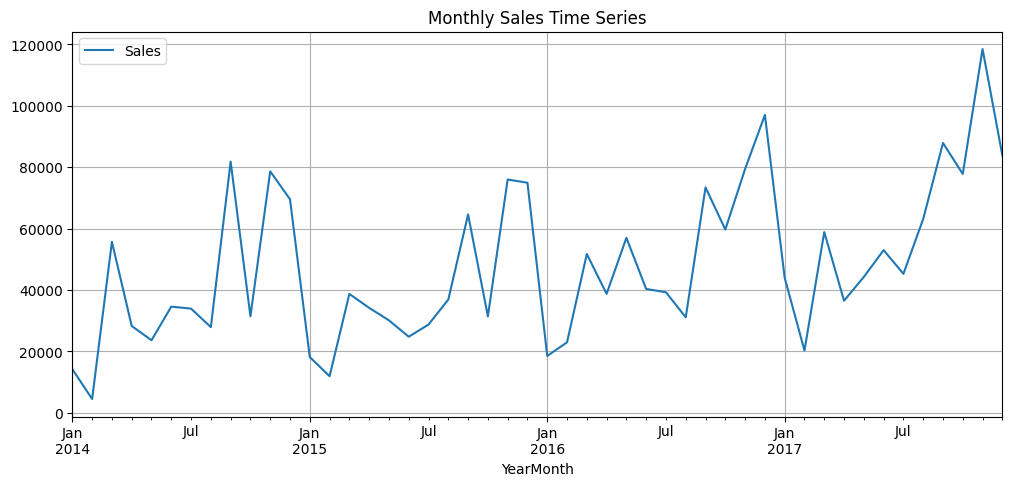

In [80]:
monthly_sales.plot(figsize=(12,5), title='Monthly Sales Time Series')
plt.grid()
plt.show()

> Pastikan pola tren sama seperti hasil EDA

##### Step 3 - Train-Test Split

In [81]:
train = monthly_sales.iloc[:-12]
test = monthly_sales.iloc[-12:]

In [82]:
print(len(train), len(test))

36 12


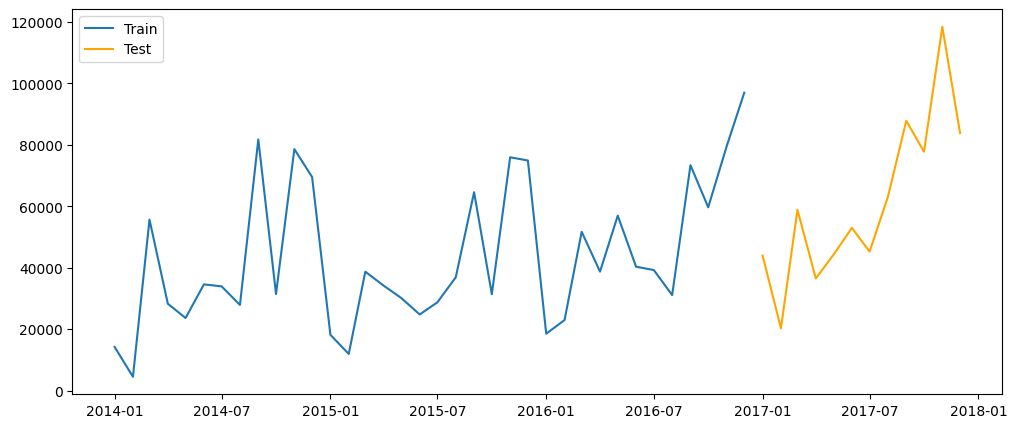

In [83]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train['Sales'], label='Train')
plt.plot(test.index, test['Sales'], label='Test', color='orange')
plt.legend()
plt.show()

##### Step 4 - Holt-winters (Triple Exponential Smoothing)

> Berdasarkan EDA, kita menggunakan addictive trend + additive seasonality

In [84]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [85]:
hw_model = ExponentialSmoothing(
    train['Sales'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

hw_fit = hw_model.fit()

In [86]:
forecast = hw_fit.forecast(12)

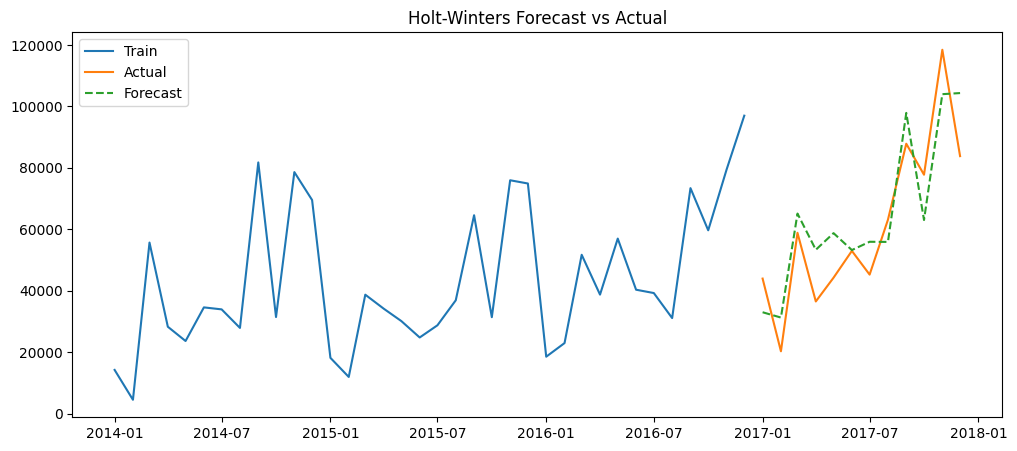

In [87]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train['Sales'], label='Train')
plt.plot(test.index, test['Sales'], label='Actual')
plt.plot(forecast.index, forecast.values, label='Forecast', linestyle='--')
plt.legend()
plt.title('Holt-Winters Forecast vs Actual')
plt.show()

##### Evaluasi Model

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(test['Sales'], forecast)
print(f"MAPE: {mape:.2%}")

MAPE: 22.59%


#### Real Forecasting

In [100]:
hw_model_rf = ExponentialSmoothing(
    monthly_sales['Sales'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

hw_fit_rf = hw_model_rf.fit()

In [101]:
forecast_rf = hw_fit_rf.forecast(12)

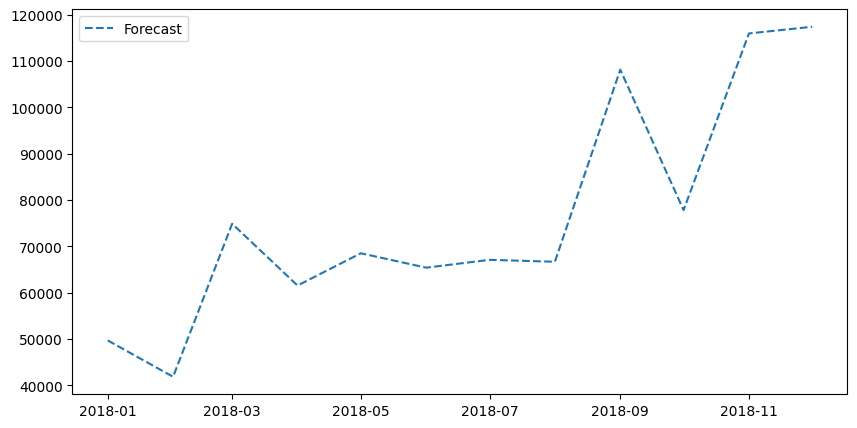

In [104]:
plt.figure(figsize=(10,5))
# plt.plot(monthly_sales.index, monthly_sales['Sales'], label='Train')
plt.plot(forecast_rf.index, forecast_rf.values, label='Forecast', linestyle='--')
plt.legend()
plt.show()